Hey so I screwed up and got my PTDE file deleted. Nice! Now to recreate it, I guess. Let me see what I can do from memory and my notes.

Normalizing initial state


10000149.284511363it [00:04, 2017183.72it/s, Semilat: 9.1, Ecc 0.3, Peri: 7.0]                             


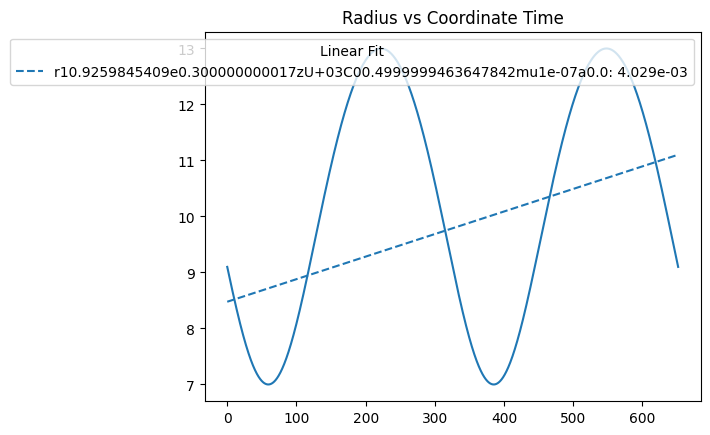

10002159.05655373it [00:00, 11531076.07it/s, Semilat: 9.1, Ecc 0.3, Peri: 7.0]                               


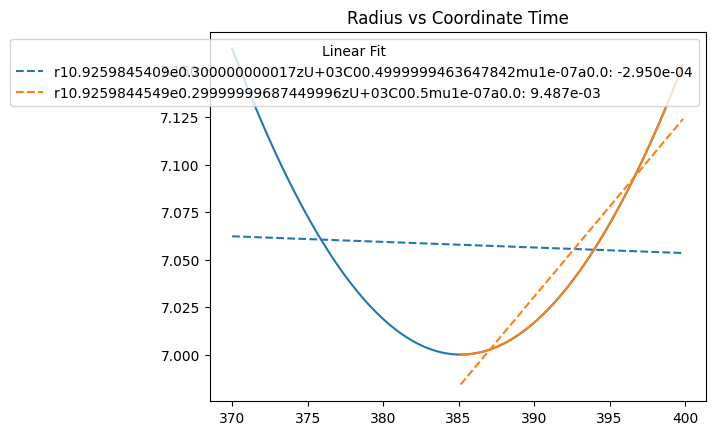

In [17]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)

# A function that interpolates data to find the state at the most recent periapse
def get_peri_state(data):
    # find most recent chunk of data that has a periapse (not robust, redo this later maybe)
    curve_test, start = False, -1
    while curve_test == False:
        if 1 in np.sign(data["raw"][data["trackix"][start]:, 5]):
            curve_test = True
        else:
            start -= 1
    #get the index of the point closest to periapse
    ix = data["trackix"][start] + op.get_index(data["raw"][data["trackix"][start]:,1], 0)
    if len(data["time"]) - ix >= 3:
        a, b = -3, 3
    else:
        a, b = 6 - (len(data["time"]) - ix), len(data["time"]) - ix
    #approximate periapse region as parabola and find minimum
    #print(a, b)
    #print(data["time"][ix+a:ix+b], data["raw"][ix+a:ix+b, 1])
    p = np.polyfit(data["time"][ix+a:ix+b], data["raw"][ix+a:ix+b, 1], 2)
    tp = np.roots(np.polyder(p))[0]
    #get state
    peri_state = np.array([np.polyval(np.polyfit(data["time"][ix+a:ix+b], data["raw"][ix+a:ix+b, i], 2), tp) for i in range(8)])
    return peri_state

test = ml.EMRIGenerator(0.0, 1e-7, "rad_orbit > 2", params=[10, 0.3, np.pi/2])
op.plotvalue3(test, "time", "radius")
peri = get_peri_state(test)
test2 = ml.EMRIGenerator(0.0, 1e-7, "rad_orbit > 2", pos=peri[:4], veltrue=peri[4:])
op.plotvalue3([test, test2], "time", "radius", start=370, end=400)

Normalizing initial state


10002133.418199712it [00:05, 1999726.69it/s, Semilat: 9.1, Ecc 0.3, Peri: 7.0]                              
10003630.499767194it [00:00, 20727184.42it/s, Semilat: 9.102, Ecc 0.3, Peri: 7.0]                              
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10005740.035136322it [00:00, 22395707.89it/s, Semilat: 9.103, Ecc 0.3, Peri: 7.0]                              
10001470.848291613it [00:00, 20392738.58it/s, Semilat: 9.105, Ecc 0.301, Peri: 7.0]                              
10001060.705492863it [00:00, 21433635.26it/s, Semilat: 9.107, Ecc 0.301, Peri: 7.0]                             
10003465.507892448it [00:00, 19969499.25it/s, Semilat: 9.109, Ecc 0.301, Peri: 7.001]                              


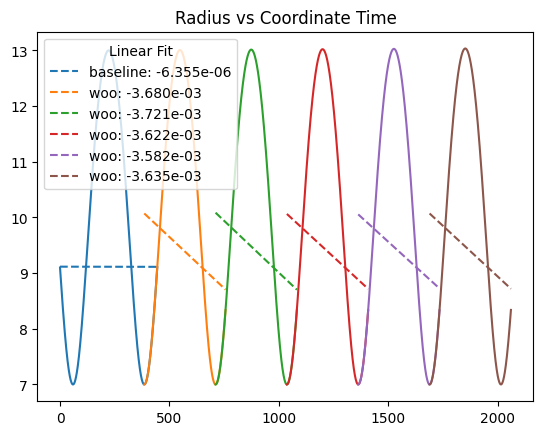

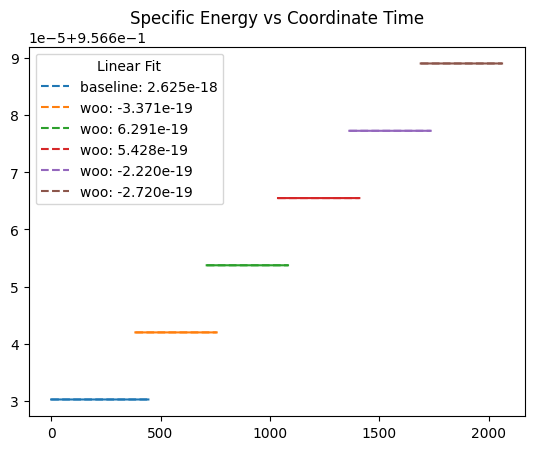

In [19]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
importlib.reload(ml)
importlib.reload(mm)
importlib.reload(op)

#Make the function that actually rips stuff off
def PTDE_thing(spin, state, mass_frac=0.001, circ=True):
    cons = ml.getCons_2(state, spin)
    turns, flats, zs = mm.root_getter(*cons, spin)
    inc = np.arccos(min(1.0, np.mean(np.abs(zs[1:3]))))
    if circ == True:
        dis_state = mm.set_u_kerr(spin, params=[state[1], 0.0, inc], pos=state[:4])[0]
    else:
        g = lambda r, a: 2*a*r
        h = lambda r, a, z: r*(r - 2) + (r**2 - 2*r + a**2)*(z**2)/(1 - z**2)
        j = lambda r, a: 2*r*(r**2 + a**2)
        if cons[1] >= 0:
            L_func = lambda r, a, z: (-1/h(r, a, z))*(g(r, a) - np.sqrt(g(r, a)**2 + h(r, a, z)*j(r, a)))   #prograde
        else:
            L_func = lambda r, a, z: (-1/h(r, a, z))*(g(r, a) - np.sqrt(g(r, a)**2 + h(r, a, z)*j(r, a)))   #retrograde
        L = L_func(state[1], spin, np.cos(inc))
        dis_state = mm.set_u_kerr(spin, cons=[1, L, ((L*np.cos(inc))**2)/(1 - np.cos(inc)**2)], pos=state[:4])[0]
    final_state = (state - mass_frac*dis_state)/(1 - mass_frac)
    return final_state


test = ml.EMRIGenerator(0.0, 1e-7, "rad_orbit > 1.5", params=[10, 0.3, np.pi/2], err_target=1e-15, label="baseline")
stuff = [test]
for i in range(5):
    #op.plotvalue3(stuff, "time", "radius")
    peri = get_peri_state(stuff[-1])
    new_state = PTDE_thing(0.0, peri)
    state = ml.EMRIGenerator(0.0, (0.001**(i+1))*1e-7, "rad_orbit > 1.2", pos=new_state[:4], veltrue=new_state[4:], err_target=1e-15, label="woo")
    stuff.append(state)

op.plotvalue3(stuff, "time", "radius")
op.plotvalue3(stuff, "time", "energy")